MACHINE-LEARNING PREDICTION RESULTS
Mean Absolute Error:     5.51
Root Mean Squared Error: 8.31
R-squared score:         0.799

ROUTING OPTIMIZATION RESULTS
Static routing overload:     2518.80
Predictive routing overload: 33.77
Overload reduction:          98.66%
Static unused capacity:      815.85
Predictive unused capacity:  5080.82

SAMPLE ROUTING DECISIONS
 time  traffic  predicted_traffic  static_capacity  predictive_capacity  static_overload  predictive_overload
  804   164.13             163.34              160                  180             4.13                  0.0
  805   164.69             166.73              160                  180             4.69                  0.0
  806   167.01             167.80              160                  180             7.01                  0.0
  807   163.95             167.82              160                  180             3.95                  0.0
  808   174.64             168.16              160                  180            14.

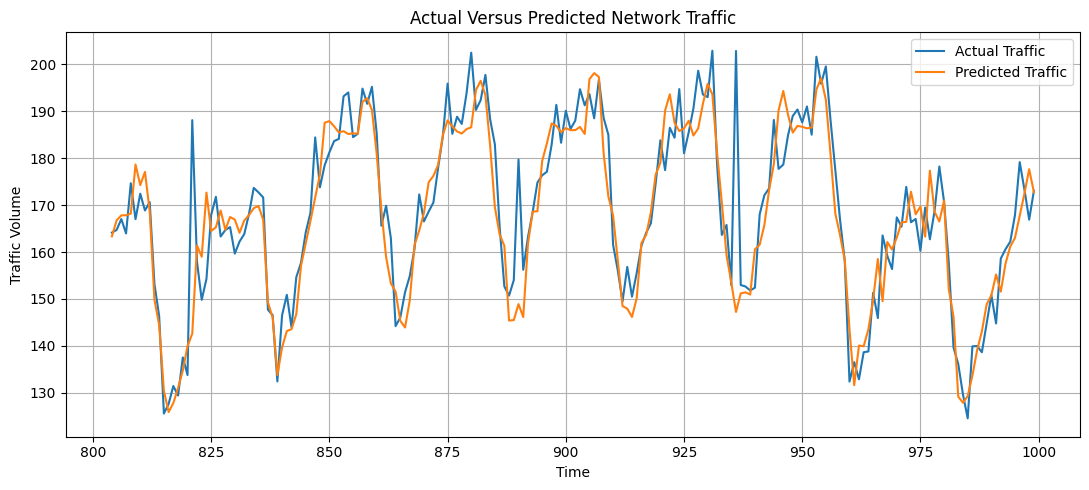

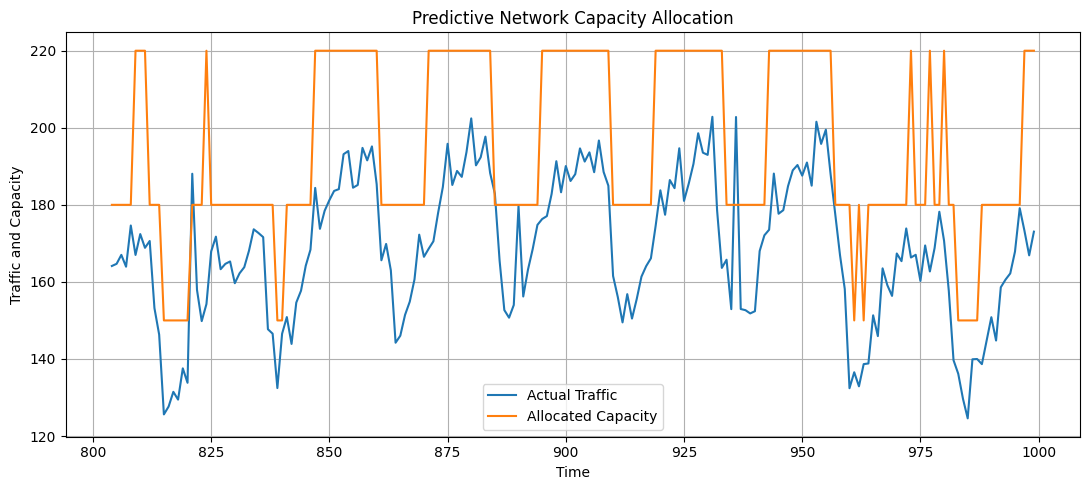

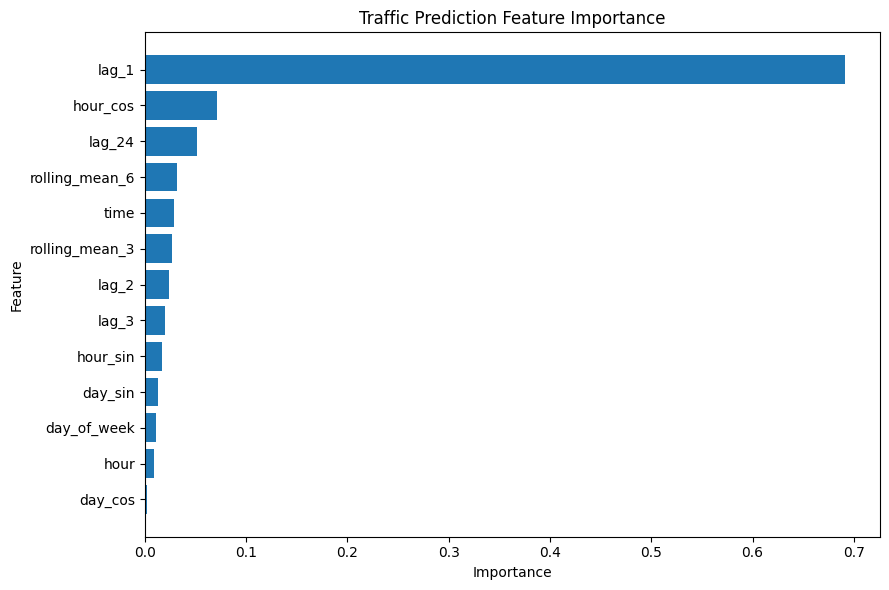

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


# Generate simulated network traffic
def generate_traffic_data(samples=1000):
    time = np.arange(samples)
    hour = time % 24
    day = (time // 24) % 7

    daily = 35 + 20 * np.sin(2 * np.pi * (hour - 6) / 24)
    evening = 30 * np.exp(-((hour - 19) ** 2) / 10)
    weekly = np.where(day < 5, 15, -5)
    trend = 0.02 * time
    noise = np.random.normal(0, 5, samples)

    bursts = np.zeros(samples)
    locations = np.random.choice(samples, 25, replace=False)
    bursts[locations] = np.random.uniform(20, 60, 25)

    traffic = np.maximum(
        100 + daily + evening + weekly + trend + noise + bursts,
        0
    )

    return pd.DataFrame({
        "time": time,
        "hour": hour,
        "day_of_week": day,
        "traffic": traffic
    })


# Create features from previous traffic values
def create_features(data):
    df = data.copy()

    for lag in [1, 2, 3, 24]:
        df[f"lag_{lag}"] = df["traffic"].shift(lag)

    for window in [3, 6]:
        df[f"rolling_mean_{window}"] = (
            df["traffic"].shift(1).rolling(window).mean()
        )

    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["day_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
    df["day_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

    return df.dropna().reset_index(drop=True)


# Prepare data
traffic_data = generate_traffic_data()
model_data = create_features(traffic_data)

features = [
    "time", "hour", "day_of_week",
    "lag_1", "lag_2", "lag_3", "lag_24",
    "rolling_mean_3", "rolling_mean_6",
    "hour_sin", "hour_cos", "day_sin", "day_cos"
]

X = model_data[features]
y = model_data["traffic"]

split = int(len(model_data) * 0.80)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]


# Train model
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=2,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

model.fit(X_train, y_train)
predictions = model.predict(X_test)


# Evaluate model
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("=" * 55)
print("MACHINE-LEARNING PREDICTION RESULTS")
print("=" * 55)
print(f"Mean Absolute Error:     {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R-squared score:         {r2:.3f}")


# Apply static and predictive routing
results = model_data.iloc[split:].copy()
results["predicted_traffic"] = predictions
results["static_capacity"] = 160

results["predictive_capacity"] = np.select(
    [
        predictions >= 200,
        predictions >= 170,
        predictions >= 140
    ],
    [260, 220, 180],
    default=150
)

results["static_overload"] = np.maximum(
    results["traffic"] - results["static_capacity"], 0
)

results["predictive_overload"] = np.maximum(
    results["traffic"] - results["predictive_capacity"], 0
)

results["static_unused_capacity"] = np.maximum(
    results["static_capacity"] - results["traffic"], 0
)

results["predictive_unused_capacity"] = np.maximum(
    results["predictive_capacity"] - results["traffic"], 0
)


# Calculate totals
static_overload = results["static_overload"].sum()
predictive_overload = results["predictive_overload"].sum()
static_unused = results["static_unused_capacity"].sum()
predictive_unused = results["predictive_unused_capacity"].sum()

overload_reduction = (
    (static_overload - predictive_overload)
    / static_overload
    * 100
    if static_overload > 0
    else 0
)


print("\n" + "=" * 55)
print("ROUTING OPTIMIZATION RESULTS")
print("=" * 55)
print(f"Static routing overload:     {static_overload:.2f}")
print(f"Predictive routing overload: {predictive_overload:.2f}")
print(f"Overload reduction:          {overload_reduction:.2f}%")
print(f"Static unused capacity:      {static_unused:.2f}")
print(f"Predictive unused capacity:  {predictive_unused:.2f}")


# Display sample routing decisions
columns = [
    "time",
    "traffic",
    "predicted_traffic",
    "static_capacity",
    "predictive_capacity",
    "static_overload",
    "predictive_overload"
]

print("\nSAMPLE ROUTING DECISIONS")
print(results[columns].head(15).round(2).to_string(index=False))


# Plot actual and predicted traffic
plt.figure(figsize=(11, 5))
plt.plot(results["time"], results["traffic"], label="Actual Traffic")
plt.plot(results["time"], predictions, label="Predicted Traffic")
plt.xlabel("Time")
plt.ylabel("Traffic Volume")
plt.title("Actual Versus Predicted Network Traffic")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Plot predictive capacity
plt.figure(figsize=(11, 5))
plt.plot(results["time"], results["traffic"], label="Actual Traffic")
plt.plot(
    results["time"],
    results["predictive_capacity"],
    label="Allocated Capacity"
)
plt.xlabel("Time")
plt.ylabel("Traffic and Capacity")
plt.title("Predictive Network Capacity Allocation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Plot feature importance
importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values()

plt.figure(figsize=(9, 6))
plt.barh(importance.index, importance.values)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Traffic Prediction Feature Importance")
plt.tight_layout()
plt.show()